# Near Centroid Method - Cosine Similarity Evaluation

This notebook evaluates **4 embedding models** using **Cosine Similarity** as the distance metric for the Near Centroid Method.

## Key Change
Unlike the Euclidean distance + StandardScaler approach, this notebook uses:
- **Cosine Similarity** between normalized embeddings and centroids
- **No StandardScaler** — raw embeddings are used directly
- Classification based on which centroid has higher cosine similarity

## Models Evaluated

1. `BAAI/bge-large-en-v1.5` (335M)
2. `sentence-transformers/all-MiniLM-L6-v2` (22M)
3. `intfloat/e5-small-v2` (33M)
4. `BAAI/bge-small-en-v1.5` (33M)

## Setup

- **Runtime**: Kaggle with GPU T4 (or any CUDA-capable GPU)
- **Dataset**: `guardrailer_dataset_v1.parquet` from Kaggle
- **Sample size**: 10,000 stratified samples (80/20 train/test split)

In [3]:
# Install dependencies
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn

In [4]:
import os
import json
import pickle
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from datetime import datetime
from numpy.linalg import norm

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

SAMPLE_SIZE = 10000
TEST_SIZE = 0.2
CHECKPOINT_DIR = Path('/kaggle/working/checkpoints_cosine')
OUTPUT_DIR = Path('/kaggle/working')

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'\nConfiguration set!')
print(f'Sample size: {SAMPLE_SIZE}')
print(f'Test size: {TEST_SIZE}')
print(f'Random seed: {RANDOM_SEED}')
print(f'Distance metric: Cosine Similarity')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB

Configuration set!
Sample size: 10000
Test size: 0.2
Random seed: 42
Distance metric: Cosine Similarity


## 1. Load and Prepare Dataset

In [5]:
def load_dataset():
    """Load and prepare the Guardrailer dataset."""
    dataset_paths = [
        '/kaggle/input/datasets/prashannadeveloper/guardrailer-dataset-v1/guardrailer_dataset_v1.parquet',
        '/kaggle/input/guardrailer-dataset-v1/guardrailer_dataset_v1.parquet',
        'guardrailer_dataset_v1.parquet',
        '../input/guardrailer-dataset-v1/guardrailer_dataset_v1.parquet'
    ]
    
    df = None
    for path in dataset_paths:
        if os.path.exists(path):
            df = pd.read_parquet(path)
            print(f'Loaded dataset from: {path}')
            break
    
    if df is None:
        raise FileNotFoundError('Dataset not found.')
    
    print(f'\nDataset shape: {df.shape}')
    print(f'\nColumn names: {df.columns.tolist()}')
    
    label_candidates = ['label', 'Label', 'labels', 'class', 'target', 'category', 'y', 'is_malicious', 'malicious']
    label_col = None
    for candidate in label_candidates:
        if candidate in df.columns:
            label_col = candidate
            break
    
    if label_col is None:
        value_counts = {col: df[col].nunique() for col in df.columns}
        label_col = min(value_counts, key=value_counts.get)
        print(f'\nWarning: No common label column found. Using "{label_col}" as label column.')
    
    if label_col != 'label':
        print(f'Renaming column "{label_col}" to "label"')
        df = df.rename(columns={label_col: 'label'})
    
    prompt_candidates = ['prompt', 'text', 'input', 'message', 'content', 'query', 'instruction', 'sentence']
    prompt_col = None
    for candidate in prompt_candidates:
        if candidate in df.columns:
            prompt_col = candidate
            break
    
    if prompt_col is None:
        str_lengths = {}
        for col in df.columns:
            if df[col].dtype == 'object':
                str_lengths[col] = df[col].astype(str).str.len().mean()
        if str_lengths:
            prompt_col = max(str_lengths, key=str_lengths.get)
            print(f'Warning: No common prompt column found. Using "{prompt_col}" as prompt column.')
        else:
            raise ValueError('No text column found in dataset.')
    
    if prompt_col != 'prompt':
        print(f'Renaming column "{prompt_col}" to "prompt"')
        df = df.rename(columns={prompt_col: 'prompt'})
    
    print(f'\nLabel distribution:')
    print(df['label'].value_counts())
    
    return df

df = load_dataset()

Loaded dataset from: /kaggle/input/datasets/prashannadeveloper/guardrailer-dataset-v1/guardrailer_dataset_v1.parquet

Dataset shape: (722842, 8)

Column names: ['id', 'prompt_text', 'is_malicious', 'attack_category', 'attack_technique', 'risk_level', 'source_dataset', 'length_norm']
Renaming column "is_malicious" to "label"
Renaming column "prompt_text" to "prompt"

Label distribution:
label
True     433066
False    289776
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split as _train_test_split

def sample_dataset(df, sample_size=SAMPLE_SIZE, random_state=RANDOM_SEED):
    """Sample dataset with stratification."""
    if len(df) > sample_size:
        df_sampled, _ = _train_test_split(df, train_size=sample_size, stratify=df['label'], random_state=random_state)
        print(f'Sampled {sample_size} from {len(df)} total samples')
    else:
        df_sampled = df
        print(f'Using all {len(df)} samples (less than requested {sample_size})')
    
    print(f'\nSampled label distribution:')
    print(df_sampled['label'].value_counts())
    
    return df_sampled

df_sampled = sample_dataset(df)

Sampled 10000 from 722842 total samples

Sampled label distribution:
label
True     5991
False    4009
Name: count, dtype: int64


In [7]:
def split_dataset(df, test_size=TEST_SIZE, random_state=RANDOM_SEED):
    """Split dataset into train and test sets."""
    X_train, X_test, y_train, y_test = train_test_split(
        df['prompt'].values,
        df['label'].values,
        test_size=test_size,
        random_state=random_state,
        stratify=df['label'].values
    )
    
    print(f'Train size: {len(X_train)}')
    print(f'Test size: {len(X_test)}')
    print(f'\nTrain label distribution:')
    unique, counts = np.unique(y_train, return_counts=True)
    for label, count in zip(unique, counts):
        print(f'  {label}: {count} ({count/len(y_train)*100:.1f}%)')
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_dataset(df_sampled)

Train size: 8000
Test size: 2000

Train label distribution:
  False: 3207 (40.1%)
  True: 4793 (59.9%)


## 2. Near Centroid Classifier (Cosine Similarity)

In [8]:
class NearCentroidClassifierCosine:
    """Near Centroid Method classifier using Cosine Similarity."""
    
    def __init__(self):
        self.centroids = {}  # L2-normalized centroids
        self.is_fitted = False
    
    def fit(self, X, y):
        """Compute centroids from training data."""
        # Compute centroids for each class
        unique_classes = np.unique(y)
        for cls in unique_classes:
            mask = y == cls
            centroid = np.mean(X[mask], axis=0)
            # L2-normalize centroid
            centroid = centroid / norm(centroid)
            self.centroids[cls] = centroid
        
        self.is_fitted = True
        print(f'Computed centroids for classes: {list(self.centroids.keys())}')
        for cls, centroid in self.centroids.items():
            print(f'  Class {cls}: centroid shape = {centroid.shape}, norm = {norm(centroid):.4f}')
    
    def _cosine_similarity(self, X):
        """Compute cosine similarity between samples and centroids."""
        # L2-normalize input embeddings
        X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
        
        similarities = {}
        for cls, centroid in self.centroids.items():
            # Cosine similarity = dot product of normalized vectors
            similarities[cls] = X_norm @ centroid
        
        return similarities
    
    def predict(self, X):
        """Predict class labels based on highest cosine similarity."""
        if not self.is_fitted:
            raise ValueError('Classifier not fitted yet. Call fit() first.')
        
        similarities = self._cosine_similarity(X)
        
        # Classify based on which centroid has higher similarity
        classes = sorted(self.centroids.keys())
        sim_matrix = np.column_stack([similarities[cls] for cls in classes])
        predictions = np.array([classes[i] for i in np.argmax(sim_matrix, axis=1)])
        
        return predictions
    
    def predict_proba(self, X):
        """Predict class probabilities based on cosine similarity."""
        if not self.is_fitted:
            raise ValueError('Classifier not fitted yet. Call fit() first.')
        
        similarities = self._cosine_similarity(X)
        
        # Convert similarities to probabilities using softmax
        classes = sorted(self.centroids.keys())
        sim_matrix = np.column_stack([similarities[cls] for cls in classes])
        
        # Softmax to convert similarities to probabilities
        exp_sim = np.exp(sim_matrix - np.max(sim_matrix, axis=1, keepdims=True))
        probabilities = exp_sim / np.sum(exp_sim, axis=1, keepdims=True)
        
        return probabilities
    
    def get_similarities(self, X):
        """Get cosine similarities to each centroid."""
        if not self.is_fitted:
            raise ValueError('Classifier not fitted yet. Call fit() first.')
        
        return self._cosine_similarity(X)

print('Near Centroid Classifier (Cosine Similarity) defined!')

Near Centroid Classifier (Cosine Similarity) defined!


## 3. Model Evaluation Pipeline

In [9]:
def clear_gpu():
    """Clear GPU cache."""
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
        gc.collect()

def generate_embeddings(model_name, texts, batch_size=128):
    """Generate embeddings using specified model."""
    clear_gpu()
    print(f'\nLoading model: {model_name}')
    model = SentenceTransformer(model_name, trust_remote_code=True, device=DEVICE)
    
    max_seq_len = model.max_seq_length
    print(f'Model max sequence length: {max_seq_len}')
    
    max_chars = max_seq_len * 4
    tokenizer = model.tokenizer
    truncated_texts = []
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='.*Token indices sequence length.*')
        for t in texts:
            text = str(t) if not isinstance(t, str) else t
            if len(text) > max_chars:
                text = text[:max_chars]
            tokens = tokenizer.encode(
                text,
                add_special_tokens=False,
                truncation=True,
                max_length=max_seq_len
            )
            text = tokenizer.decode(tokens, skip_special_tokens=True)
            truncated_texts.append(text)
    
    print(f'Generating embeddings for {len(truncated_texts)} texts...')
    embeddings = model.encode(
        truncated_texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    
    print(f'Embedding shape: {embeddings.shape}')
    del model
    clear_gpu()
    return embeddings

print('Embedding generation function defined!')

Embedding generation function defined!


In [10]:
def evaluate_near_centroid_cosine(X_train_emb, y_train, X_test_emb, y_test):
    """Evaluate using Near Centroid Method with Cosine Similarity."""
    # Initialize and fit classifier
    classifier = NearCentroidClassifierCosine()
    classifier.fit(X_train_emb, y_train)
    
    # Get predictions
    y_pred = classifier.predict(X_test_emb)
    y_proba = classifier.predict_proba(X_test_emb)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    # For AUC-ROC, we need probabilities for the positive class
    if len(np.unique(y_test)) == 2:
        classes = sorted(np.unique(y_test))
        pos_idx = classes.index(1) if 1 in classes else len(classes) - 1
        auc_roc = roc_auc_score(y_test, y_proba[:, pos_idx])
        
        # Get ROC curve data
        fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, pos_idx])
    else:
        auc_roc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        fpr, tpr, thresholds = None, None, None
    
    # Calculate centroid cosine similarity
    centroid_sim = None
    if len(classifier.centroids) == 2:
        centroids = list(classifier.centroids.values())
        centroid_sim = np.dot(centroids[0], centroids[1])  # Already normalized
    
    # Get similarities for visualization
    similarities = classifier.get_similarities(X_test_emb)
    
    # Calculate margin (difference between similarities to two centroids)
    if len(similarities) == 2:
        classes = sorted(similarities.keys())
        margin = similarities[classes[1]] - similarities[classes[0]]  # malicious - benign
    else:
        margin = None
    
    metrics = {
        'accuracy': accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'auc_roc': auc_roc,
        'centroid_similarity': centroid_sim,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'similarities': similarities,
        'margin': margin,
        'classifier': classifier
    }
    
    return metrics

print('Evaluation function defined!')

Evaluation function defined!


## 4. Run Evaluation for All Models

In [11]:
# Define models to evaluate
MODELS = [
    'BAAI/bge-large-en-v1.5',
    'sentence-transformers/all-MiniLM-L6-v2',
    'intfloat/e5-small-v2',
    'BAAI/bge-small-en-v1.5'
]

MODEL_PARAMS = {
    'BAAI/bge-large-en-v1.5': '335M',
    'sentence-transformers/all-MiniLM-L6-v2': '22M',
    'intfloat/e5-small-v2': '33M',
    'BAAI/bge-small-en-v1.5': '33M'
}

print('Models to evaluate:')
for i, model in enumerate(MODELS, 1):
    print(f'  {i}. {model} ({MODEL_PARAMS[model]})')

Models to evaluate:
  1. BAAI/bge-large-en-v1.5 (335M)
  2. sentence-transformers/all-MiniLM-L6-v2 (22M)
  3. intfloat/e5-small-v2 (33M)
  4. BAAI/bge-small-en-v1.5 (33M)


In [12]:
# Check for existing checkpoints
def load_checkpoint(model_name):
    """Load checkpoint if exists."""
    checkpoint_file = CHECKPOINT_DIR / f'{model_name.replace("/", "_")}_checkpoint.pkl'
    if checkpoint_file.exists():
        with open(checkpoint_file, 'rb') as f:
            checkpoint = pickle.load(f)
        print(f'Loaded checkpoint for {model_name}')
        return checkpoint
    return None

def save_checkpoint(model_name, embeddings, metrics):
    """Save checkpoint."""
    checkpoint_file = CHECKPOINT_DIR / f'{model_name.replace("/", "_")}_checkpoint.pkl'
    checkpoint = {
        'model_name': model_name,
        'train_embeddings': embeddings['train'],
        'test_embeddings': embeddings['test'],
        'metrics': {k: v for k, v in metrics.items() if k != 'classifier'}
    }
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint, f)
    print(f'Saved checkpoint for {model_name}')

print('Checkpoint functions defined!')

Checkpoint functions defined!


In [13]:
# Run evaluation for all models
results = {}

BATCH_SIZES = {
    'BAAI/bge-large-en-v1.5': 64,
    'sentence-transformers/all-MiniLM-L6-v2': 256,
    'intfloat/e5-small-v2': 256,
    'BAAI/bge-small-en-v1.5': 256,
}

for model_name in MODELS:
    print(f'\n{"="*80}')
    print(f'Evaluating: {model_name}')
    print(f'{"="*80}')
    
    checkpoint = load_checkpoint(model_name)
    
    if checkpoint is not None:
        X_train_emb = checkpoint['train_embeddings']
        X_test_emb = checkpoint['test_embeddings']
        metrics = checkpoint['metrics']
    else:
        batch_size = BATCH_SIZES.get(model_name, 128)
        X_train_emb = generate_embeddings(model_name, X_train.tolist(), batch_size=batch_size)
        X_test_emb = generate_embeddings(model_name, X_test.tolist(), batch_size=batch_size)
        
        metrics = evaluate_near_centroid_cosine(X_train_emb, y_train, X_test_emb, y_test)
        
        save_checkpoint(model_name, {'train': X_train_emb, 'test': X_test_emb}, metrics)
    
    results[model_name] = metrics
    
    print(f'\nResults for {model_name}:')
    print(f'  Accuracy: {metrics["accuracy"]:.4f}')
    print(f'  F1-Score: {metrics["f1_score"]:.4f}')
    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall: {metrics["recall"]:.4f}')
    print(f'  AUC-ROC: {metrics["auc_roc"]:.4f}')
    if metrics['centroid_similarity'] is not None:
        print(f'  Centroid Similarity: {metrics["centroid_similarity"]:.4f}')
    
    del X_train_emb, X_test_emb
    clear_gpu()

print(f'\n{"="*80}')
print('All models evaluated!')


Evaluating: BAAI/bge-large-en-v1.5



Loading model: BAAI/bge-large-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model max sequence length: 512
Generating embeddings for 2000 texts...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding shape: (2000, 384)
Computed centroids for classes: [np.False_, np.True_]
  Class False: centroid shape = (384,), norm = 1.0000
  Class True: centroid shape = (384,), norm = 1.0000
Saved checkpoint for BAAI/bge-small-en-v1.5

Results for BAAI/bge-small-en-v1.5:
  Accuracy: 0.7000
  F1-Score: 0.7027
  Precision: 0.7120
  Recall: 0.7000
  AUC-ROC: 0.7573
  Centroid Similarity: 0.9872

All models evaluated!


## 5. Generate Visualizations

In [14]:
# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
sns.set_palette('husl')

# Shorten model names for plotting
def shorten_name(name):
    """Create short name for plotting."""
    if 'bge-large' in name:
        return 'BGE-Large'
    elif 'MiniLM' in name:
        return 'MiniLM-L6'
    elif 'e5-small' in name:
        return 'E5-Small'
    elif 'bge-small' in name:
        return 'BGE-Small'
    return name.split('/')[-1]

print('Visualization functions defined!')

Visualization functions defined!


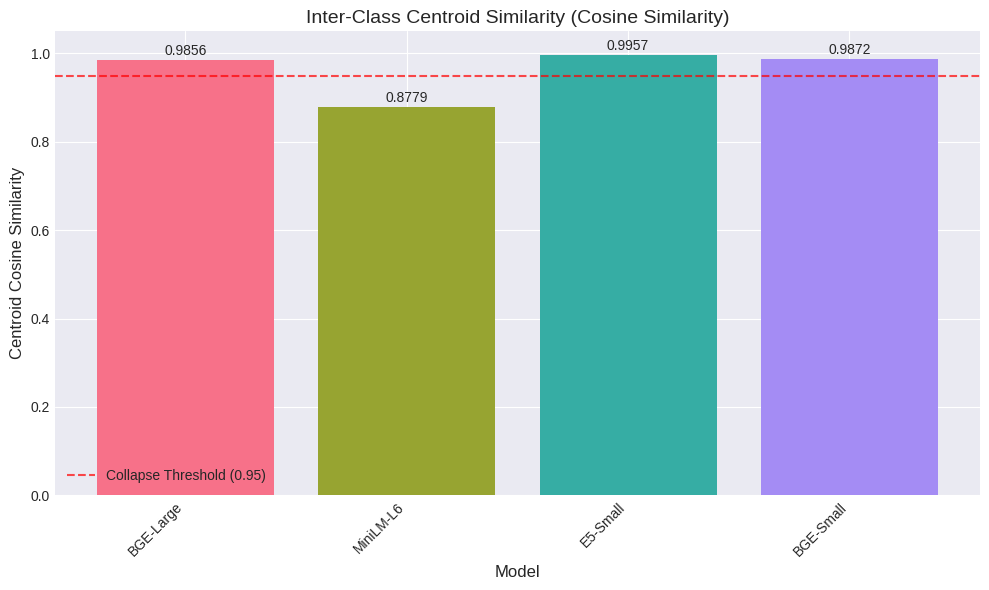

Saved: /kaggle/working/fig_centroid_similarity_cosine.png


In [15]:
# 1. Centroid Similarity Bar Chart
def plot_centroid_similarity(results, output_path):
    """Plot centroid similarity for all models."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models = []
    similarities = []
    
    for model_name, metrics in results.items():
        if metrics['centroid_similarity'] is not None:
            models.append(shorten_name(model_name))
            similarities.append(metrics['centroid_similarity'])
    
    bars = ax.bar(models, similarities, color=sns.color_palette('husl', len(models)))
    
    # Add value labels on bars
    for bar, sim in zip(bars, similarities):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{sim:.4f}', ha='center', va='bottom', fontsize=10)
    
    # Add collapse threshold line
    ax.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='Collapse Threshold (0.95)')
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Centroid Cosine Similarity', fontsize=12)
    ax.set_title('Inter-Class Centroid Similarity (Cosine Similarity)', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

plot_centroid_similarity(results, OUTPUT_DIR / 'fig_centroid_similarity_cosine.png')

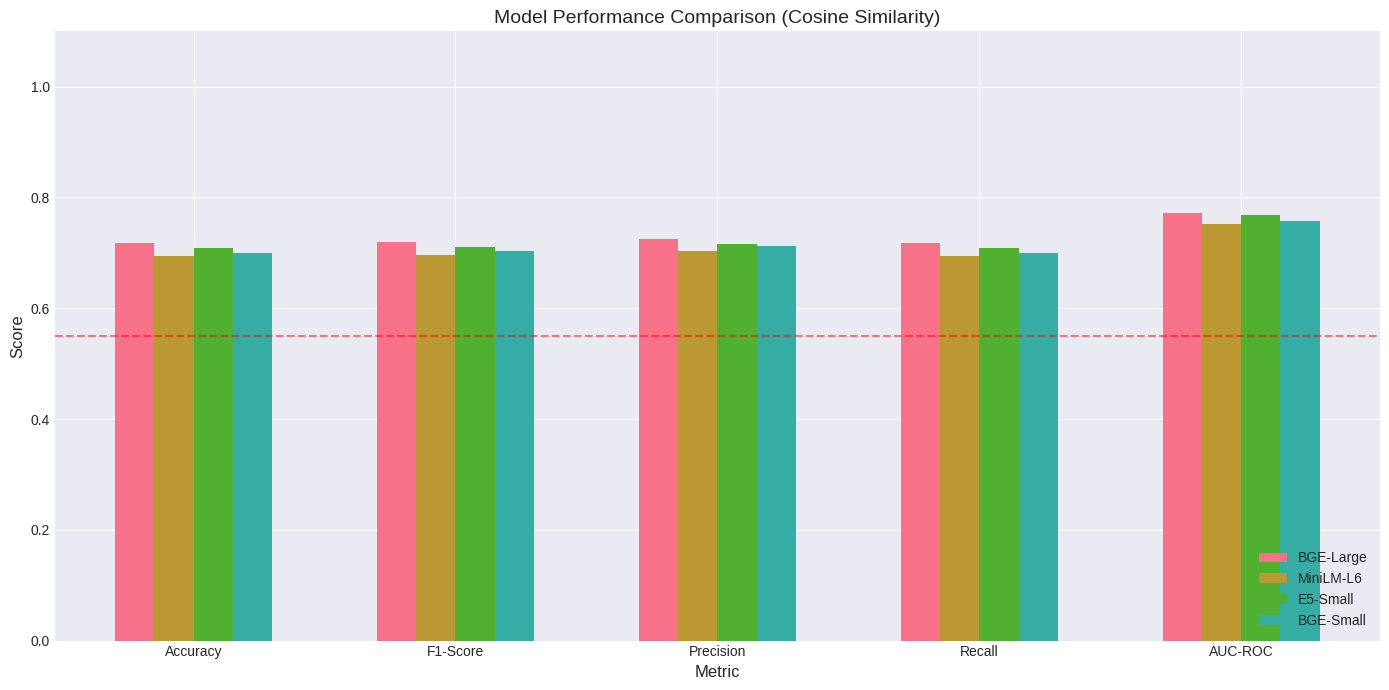

Saved: /kaggle/working/fig_performance_metrics_cosine.png


In [16]:
# 2. Multi-Metric Performance Bar Chart
def plot_performance_metrics(results, output_path):
    """Plot multiple metrics for all models."""
    metrics_to_plot = ['accuracy', 'f1_score', 'precision', 'recall', 'auc_roc']
    metric_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC']
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = np.arange(len(metrics_to_plot))
    width = 0.15
    multiplier = 0
    
    for model_name, metrics in results.items():
        offset = width * multiplier
        values = [metrics[m] for m in metrics_to_plot]
        bars = ax.bar(x + offset, values, width, label=shorten_name(model_name))
        multiplier += 1
    
    ax.set_xlabel('Metric', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison (Cosine Similarity)', fontsize=14)
    ax.set_xticks(x + width * (len(results) - 1) / 2)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right')
    ax.axhline(y=0.55, color='r', linestyle='--', alpha=0.5, label='AUC-ROC Threshold')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

plot_performance_metrics(results, OUTPUT_DIR / 'fig_performance_metrics_cosine.png')

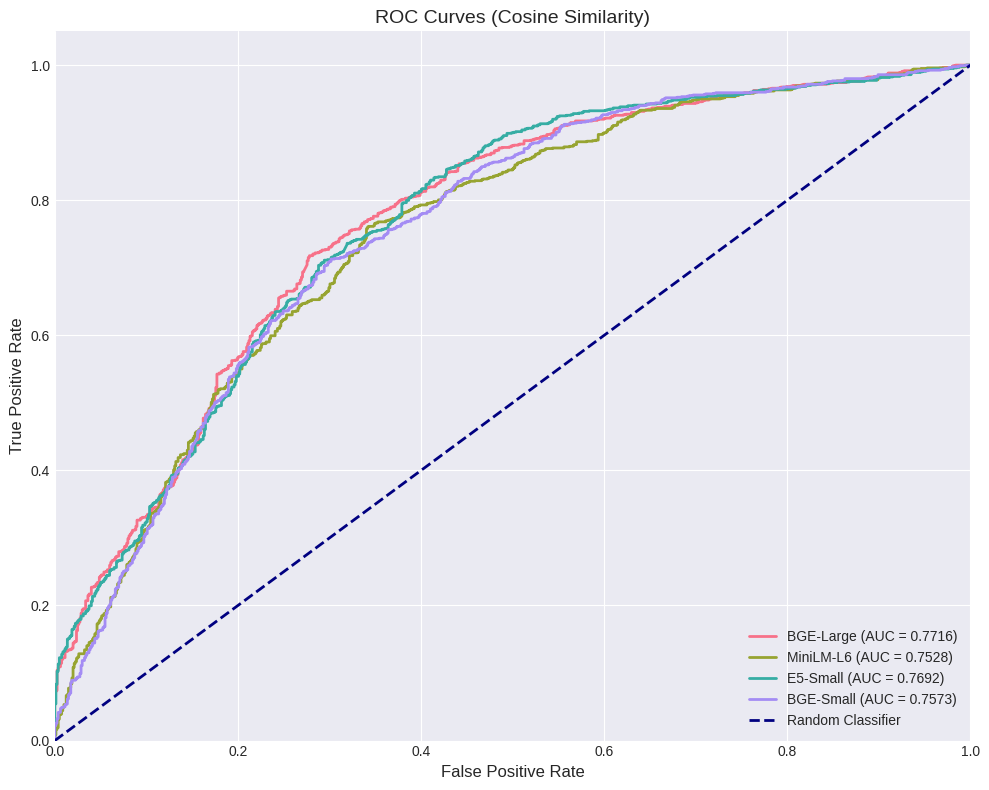

Saved: /kaggle/working/fig_roc_curves_cosine.png


In [17]:
# 3. ROC Curves
def plot_roc_curves(results, output_path):
    """Plot ROC curves for all models."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = sns.color_palette('husl', len(results))
    
    for (model_name, metrics), color in zip(results.items(), colors):
        if metrics['fpr'] is not None and metrics['tpr'] is not None:
            ax.plot(metrics['fpr'], metrics['tpr'], 
                   color=color, lw=2,
                   label=f'{shorten_name(model_name)} (AUC = {metrics["auc_roc"]:.4f})')
    
    # Plot random classifier line
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves (Cosine Similarity)', fontsize=14)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

plot_roc_curves(results, OUTPUT_DIR / 'fig_roc_curves_cosine.png')

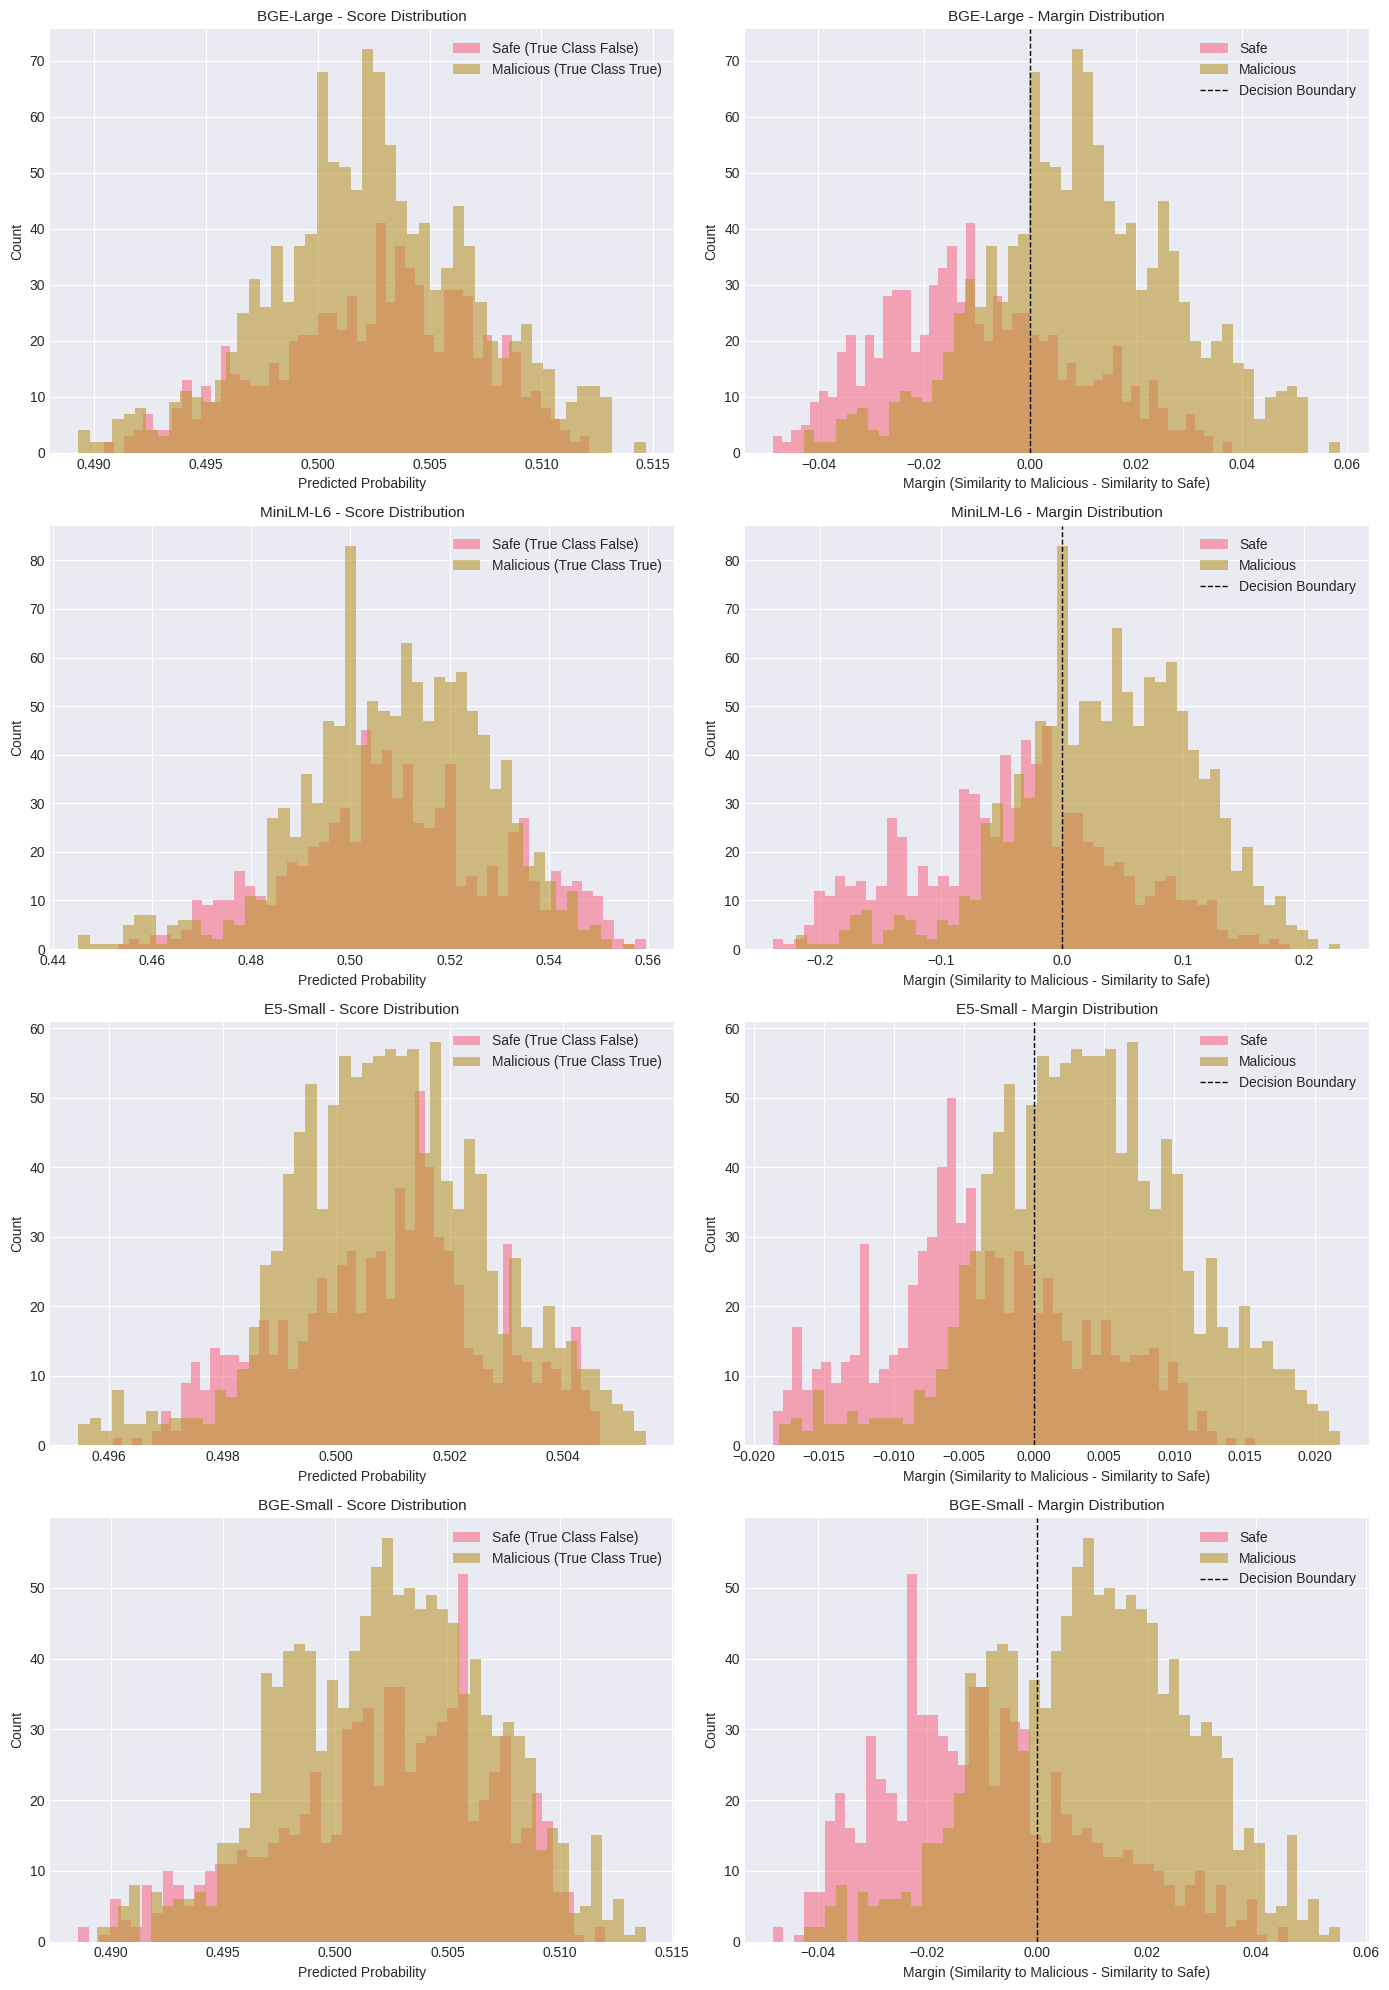

Saved: /kaggle/working/fig_score_distribution_cosine.png


In [18]:
# 4. Score Distribution and Margin Analysis
def plot_score_distribution(results, X_test, y_test, output_path):
    """Plot score distribution and margin analysis."""
    n_models = len(results)
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
    
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (model_name, metrics) in enumerate(results.items()):
        # Plot 1: Score distribution (probabilities)
        ax1 = axes[idx, 0]
        y_proba = metrics['y_proba']
        
        # Get probabilities for each class
        classes = sorted(np.unique(y_test))
        for cls_idx, cls in enumerate(classes):
            mask = y_test == cls
            label = 'Malicious' if cls == 1 else 'Safe'
            ax1.hist(y_proba[mask, cls_idx], bins=50, alpha=0.6, 
                    label=f'{label} (True Class {cls})')
        
        ax1.set_xlabel('Predicted Probability', fontsize=10)
        ax1.set_ylabel('Count', fontsize=10)
        ax1.set_title(f'{shorten_name(model_name)} - Score Distribution', fontsize=11)
        ax1.legend()
        
        # Plot 2: Margin analysis
        ax2 = axes[idx, 1]
        if metrics['margin'] is not None:
            margin = metrics['margin']
            
            # Plot histograms for each true class
            for cls in classes:
                mask = y_test == cls
                label = 'Malicious' if cls == 1 else 'Safe'
                ax2.hist(margin[mask], bins=50, alpha=0.6, label=label)
            
            ax2.axvline(x=0, color='k', linestyle='--', linewidth=1, label='Decision Boundary')
            ax2.set_xlabel('Margin (Similarity to Malicious - Similarity to Safe)', fontsize=10)
            ax2.set_ylabel('Count', fontsize=10)
            ax2.set_title(f'{shorten_name(model_name)} - Margin Distribution', fontsize=11)
            ax2.legend()
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

plot_score_distribution(results, X_test, y_test, OUTPUT_DIR / 'fig_score_distribution_cosine.png')

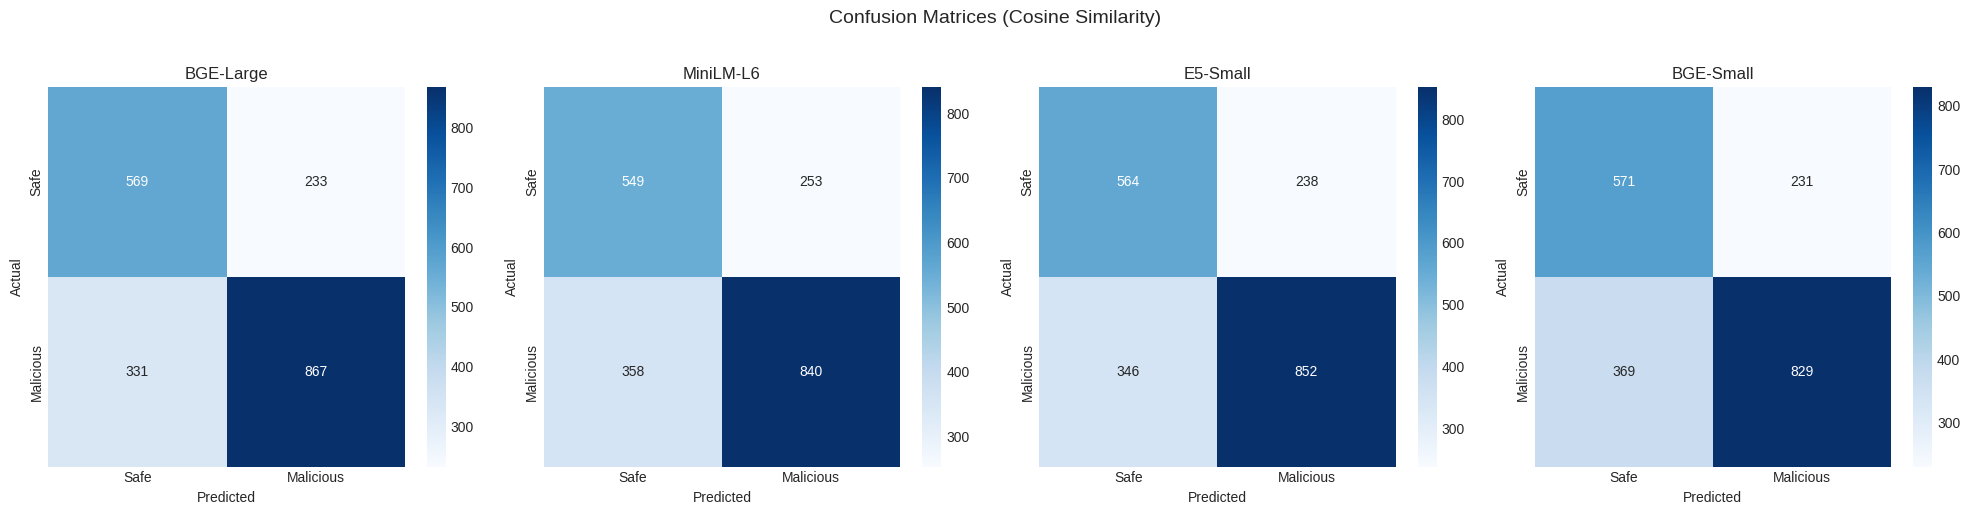

Saved: /kaggle/working/fig_confusion_matrices_cosine.png


In [19]:
# 5. Confusion Matrix Heatmaps
def plot_confusion_matrices(results, y_test, output_path):
    """Plot confusion matrices for all models."""
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for ax, (model_name, metrics) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, metrics['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Safe', 'Malicious'],
                   yticklabels=['Safe', 'Malicious'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{shorten_name(model_name)}')
    
    plt.suptitle('Confusion Matrices (Cosine Similarity)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

plot_confusion_matrices(results, y_test, OUTPUT_DIR / 'fig_confusion_matrices_cosine.png')

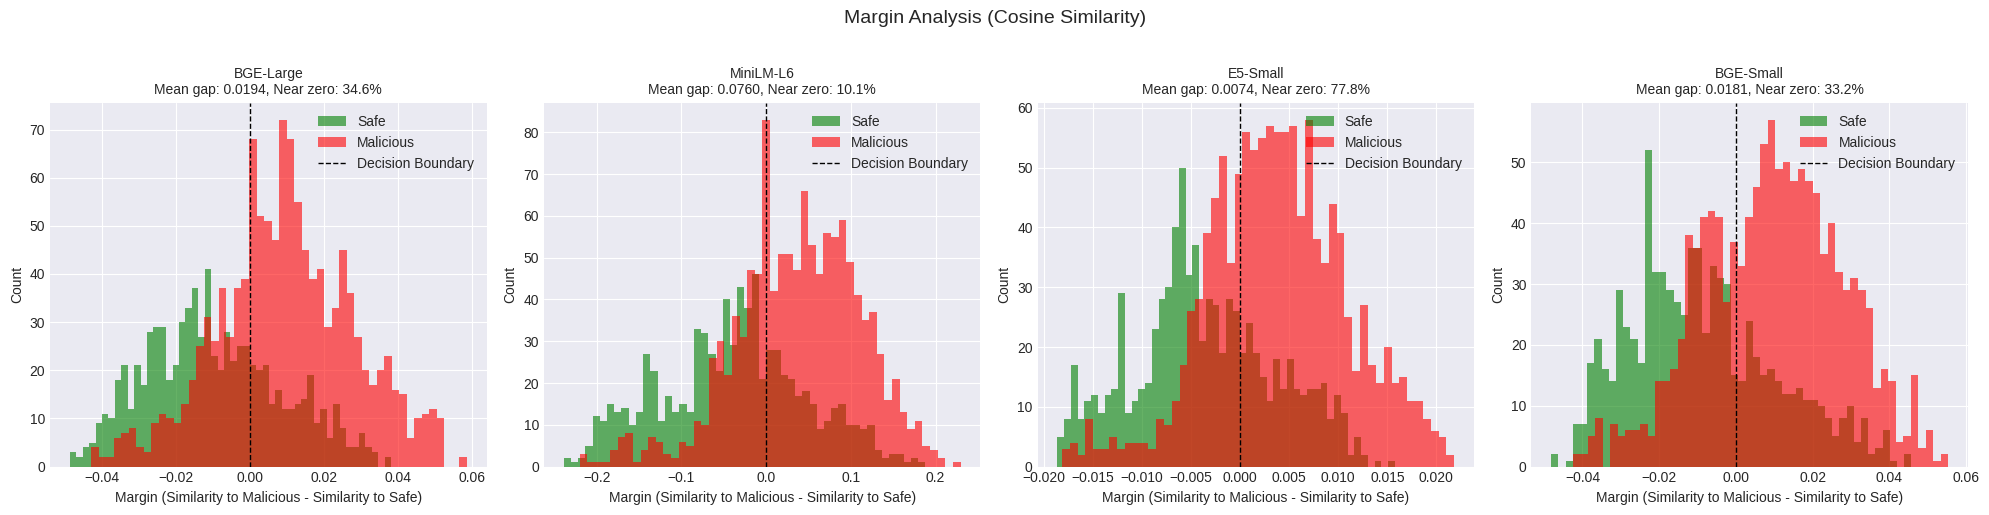

Saved: /kaggle/working/fig_margin_analysis_cosine.png


In [20]:
# 6. Margin Analysis (Cosine Similarity specific)
def plot_margin_analysis(results, y_test, output_path):
    """Plot margin analysis for cosine similarity."""
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for ax, (model_name, metrics) in zip(axes, results.items()):
        if metrics['margin'] is not None:
            margin = metrics['margin']
            
            # Plot margin distribution
            ax.hist(margin[y_test == 0], bins=50, alpha=0.6, label='Safe', color='green')
            ax.hist(margin[y_test == 1], bins=50, alpha=0.6, label='Malicious', color='red')
            ax.axvline(x=0, color='k', linestyle='--', linewidth=1, label='Decision Boundary')
            
            # Calculate and print margin statistics
            safe_margin = margin[y_test == 0]
            mal_margin = margin[y_test == 1]
            pct_near_zero = np.mean(np.abs(margin) < 0.01) * 100
            
            ax.set_xlabel('Margin (Similarity to Malicious - Similarity to Safe)', fontsize=10)
            ax.set_ylabel('Count', fontsize=10)
            ax.set_title(f'{shorten_name(model_name)}\nMean gap: {mal_margin.mean() - safe_margin.mean():.4f}, Near zero: {pct_near_zero:.1f}%', fontsize=10)
            ax.legend()
    
    plt.suptitle('Margin Analysis (Cosine Similarity)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

plot_margin_analysis(results, y_test, OUTPUT_DIR / 'fig_margin_analysis_cosine.png')

## 6. Save Results

In [21]:
# Prepare results for saving
def prepare_results_for_saving(results):
    """Prepare results dictionary for JSON/CSV export."""
    results_summary = {}
    
    for model_name, metrics in results.items():
        results_summary[model_name] = {
            'method': 'near_centroid_cosine',
            'params': MODEL_PARAMS.get(model_name, 'unknown'),
            'accuracy': float(metrics['accuracy']),
            'f1_score': float(metrics['f1_score']),
            'precision': float(metrics['precision']),
            'recall': float(metrics['recall']),
            'auc_roc': float(metrics['auc_roc']),
            'centroid_cosine_similarity': float(metrics['centroid_similarity']) if metrics['centroid_similarity'] is not None else None
        }
    
    return results_summary

# Save results to JSON
results_summary = prepare_results_for_saving(results)
json_path = OUTPUT_DIR / 'near_centroid_cosine_results.json'
with open(json_path, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'Saved JSON results: {json_path}')

# Save results to CSV
df_results = pd.DataFrame(results_summary).T
df_results.index.name = 'model'
csv_path = OUTPUT_DIR / 'near_centroid_cosine_results.csv'
df_results.to_csv(csv_path)
print(f'Saved CSV results: {csv_path}')

# Display results summary
print(f'\n{"="*80}')
print('RESULTS SUMMARY (Cosine Similarity)')
print(f'{"="*80}')
print(df_results.to_string())

Saved JSON results: /kaggle/working/near_centroid_cosine_results.json
Saved CSV results: /kaggle/working/near_centroid_cosine_results.csv

RESULTS SUMMARY (Cosine Similarity)
                                                      method params accuracy  f1_score precision  recall   auc_roc centroid_cosine_similarity
model                                                                                                                                        
BAAI/bge-large-en-v1.5                  near_centroid_cosine   335M    0.718  0.720106  0.725642   0.718  0.771558                   0.985601
sentence-transformers/all-MiniLM-L6-v2  near_centroid_cosine    22M   0.6945  0.696884   0.70307  0.6945  0.752796                   0.877934
intfloat/e5-small-v2                    near_centroid_cosine    33M    0.708  0.710319  0.716741   0.708  0.769174                   0.995672
BAAI/bge-small-en-v1.5                  near_centroid_cosine    33M      0.7  0.702715  0.712049     0.7  0.757253 

In [22]:
# Check for collapsed models
def check_collapsed_models(results, accuracy_baseline):
    """Check for collapsed models based on criteria."""
    print(f'\n{"="*80}')
    print('COLLAPSE ANALYSIS')
    print(f'{"="*80}')
    print(f'Majority-class baseline accuracy: {accuracy_baseline:.4f}')
    print(f'\nCollapse Criteria:')
    print(f'  1. Centroid Similarity > 0.95')
    print(f'  2. AUC-ROC < 0.55')
    print(f'  3. Accuracy < baseline ({accuracy_baseline:.4f})')
    print(f'\nResults:')
    
    collapsed_models = []
    
    for model_name, metrics in results.items():
        is_collapsed = True
        reasons = []
        
        # Check criterion 1
        if metrics['centroid_similarity'] is not None and metrics['centroid_similarity'] > 0.95:
            reasons.append(f'Centroid similarity ({metrics["centroid_similarity"]:.4f}) > 0.95')
        else:
            is_collapsed = False
        
        # Check criterion 2
        if metrics['auc_roc'] < 0.55:
            reasons.append(f'AUC-ROC ({metrics["auc_roc"]:.4f}) < 0.55')
        else:
            is_collapsed = False
        
        # Check criterion 3
        if metrics['accuracy'] < accuracy_baseline:
            reasons.append(f'Accuracy ({metrics["accuracy"]:.4f}) < baseline ({accuracy_baseline:.4f})')
        else:
            is_collapsed = False
        
        status = 'COLLAPSED' if is_collapsed else 'NOT COLLAPSED'
        print(f'\n{shorten_name(model_name)}: {status}')
        
        if is_collapsed:
            collapsed_models.append(model_name)
            for reason in reasons:
                print(f'  - {reason}')
        else:
            print(f'  Passed collapse checks')
    
    return collapsed_models

# Calculate baseline
unique, counts = np.unique(y_test, return_counts=True)
majority_class_count = max(counts)
accuracy_baseline = majority_class_count / len(y_test)

collapsed_models = check_collapsed_models(results, accuracy_baseline)


COLLAPSE ANALYSIS
Majority-class baseline accuracy: 0.5990

Collapse Criteria:
  1. Centroid Similarity > 0.95
  2. AUC-ROC < 0.55
  3. Accuracy < baseline (0.5990)

Results:

BGE-Large: NOT COLLAPSED
  Passed collapse checks

MiniLM-L6: NOT COLLAPSED
  Passed collapse checks

E5-Small: NOT COLLAPSED
  Passed collapse checks

BGE-Small: NOT COLLAPSED
  Passed collapse checks


In [23]:
# Final summary
print(f'\n{"="*80}')
print('EVALUATION COMPLETE')
print(f'{"="*80}')
print(f'\nMethod: Near Centroid (Cosine Similarity)')
print(f'Models evaluated: {len(results)}')
print(f'Sample size: {SAMPLE_SIZE}')
print(f'Train/Test split: {int(SAMPLE_SIZE * (1-TEST_SIZE))}/{int(SAMPLE_SIZE * TEST_SIZE)}')
print(f'\nOutput files:')
print(f'  - {OUTPUT_DIR / "near_centroid_cosine_results.json"}')
print(f'  - {OUTPUT_DIR / "near_centroid_cosine_results.csv"}')
print(f'  - {OUTPUT_DIR / "fig_centroid_similarity_cosine.png"}')
print(f'  - {OUTPUT_DIR / "fig_performance_metrics_cosine.png"}')
print(f'  - {OUTPUT_DIR / "fig_roc_curves_cosine.png"}')
print(f'  - {OUTPUT_DIR / "fig_score_distribution_cosine.png"}')
print(f'  - {OUTPUT_DIR / "fig_confusion_matrices_cosine.png"}')
print(f'  - {OUTPUT_DIR / "fig_margin_analysis_cosine.png"}')

if collapsed_models:
    print(f'\nCollapsed models:')
    for model in collapsed_models:
        print(f'  - {shorten_name(model)}')
else:
    print(f'\nNo collapsed models detected.')


EVALUATION COMPLETE

Method: Near Centroid (Cosine Similarity)
Models evaluated: 4
Sample size: 10000
Train/Test split: 8000/2000

Output files:
  - /kaggle/working/near_centroid_cosine_results.json
  - /kaggle/working/near_centroid_cosine_results.csv
  - /kaggle/working/fig_centroid_similarity_cosine.png
  - /kaggle/working/fig_performance_metrics_cosine.png
  - /kaggle/working/fig_roc_curves_cosine.png
  - /kaggle/working/fig_score_distribution_cosine.png
  - /kaggle/working/fig_confusion_matrices_cosine.png
  - /kaggle/working/fig_margin_analysis_cosine.png

No collapsed models detected.


In [24]:
# Display final results table (matching paper Table 14 format)
print(f'\n{"="*80}')
print('FINAL RESULTS TABLE (Paper Table 14 Format)')
print(f'{"="*80}\n')

df_display = pd.DataFrame({
    'Model': [name.split('/')[-1] for name in results.keys()],
    'Params': [MODEL_PARAMS[name] for name in results.keys()],
    'Centroid Cos. Sim.': [f'{results[name]["centroid_similarity"]:.3f}' if results[name]['centroid_similarity'] is not None else 'N/A' for name in results.keys()],
    'Accuracy': [f'{results[name]["accuracy"]:.1%}' for name in results.keys()],
    'F1': [f'{results[name]["f1_score"]:.3f}' for name in results.keys()],
    'AUC-ROC': [f'{results[name]["auc_roc"]:.3f}' for name in results.keys()]
})

print(df_display.to_string(index=False))
print(f'\n{"="*80}')
print('Note: Centroid Cos. Sim. = cosine similarity between normalized class centroids.')
print('High similarity (>0.95) + low AUC-ROC (~0.5) = centroid method FAILS.')
print('This confirms: cosine similarity cannot discriminate intent in embedding space.')


FINAL RESULTS TABLE (Paper Table 14 Format)

            Model Params Centroid Cos. Sim. Accuracy    F1 AUC-ROC
bge-large-en-v1.5   335M              0.986    71.8% 0.720   0.772
 all-MiniLM-L6-v2    22M              0.878    69.5% 0.697   0.753
      e5-small-v2    33M              0.996    70.8% 0.710   0.769
bge-small-en-v1.5    33M              0.987    70.0% 0.703   0.757

Note: Centroid Cos. Sim. = cosine similarity between normalized class centroids.
High similarity (>0.95) + low AUC-ROC (~0.5) = centroid method FAILS.
This confirms: cosine similarity cannot discriminate intent in embedding space.
